# Question B3 (10 marks)

Besides ensuring that your neural network performs well, it is important to be able to explain the model’s decision. **Captum** is a very handy library that helps you to do so for PyTorch models.

Many model explainability algorithms for deep learning models are available in Captum. These algorithms are often used to generate an attribution score for each feature. Features with larger scores are more ‘important’ and some algorithms also provide information about directionality (i.e. a feature with very negative attribution scores means the larger the value of that feature, the lower the value of the output).

In general, these algorithms can be grouped into two paradigms:
- **perturbation based approaches** (e.g. Feature Ablation)
- **gradient / backpropagation based approaches** (e.g. Saliency)

The former adopts a brute-force approach of removing / permuting features one by one and does not scale up well. The latter depends on gradients and they can be computed relatively quickly. But unlike how backpropagation computes gradients with respect to weights, gradients here are computed **with respect to the input**. This gives us a sense of how much a change in the input affects the model’s outputs.





---



---



In [8]:
# !pip install captum

In [9]:
SEED = 42

import os

import random
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

from captum.attr import Saliency, DeepLift, IntegratedGradients, GradientShap, FeatureAblation

import matplotlib.pyplot as plt

## Configuration for Google Colab
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/SC4001 Neural Network')

from common_utils import set_seed

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
no_features = 6
no_neurons = 5
no_labels = 1
learning_rate = 0.0005
batch_size = 50
no_epochs = 200

1.First, load the dataset following the splits in Question B1. To keep things simple, we will **limit our analysis to numeric / continuous features only**. Drop all categorical features from the dataframes. Do not standardise the numerical features for now.



In [11]:
# YOUR CODE HERE

df = pd.read_csv('/content/drive/MyDrive/SC4001 Neural Network/hdb_price_prediction.csv')

# Filter Out data from year 2022 and 2023
df = df[df['year'].isin([2019, 2020, 2021]) | (df['year'] < 2019)]

# Define features that should be used
numeric_features     = ['dist_to_nearest_stn', 'dist_to_dhoby', 'degree_centrality', 'eigenvector_centrality', 'remaining_lease_years', 'floor_area_sqm']
prediction_target    = ['resale_price']
all_features         = numeric_features + prediction_target

# Split features for train, validation & test by year
train_df = df[df['year'] <= 2019]
val_df   = df[df['year'] == 2020]
test_df  = df[df['year'] == 2021]

# Separate features and target
train_df = train_df[all_features]
val_df   = val_df[all_features]
test_df  = test_df[all_features]

In [12]:
X_train = train_df.iloc[:,:-1]
y_train = train_df.iloc[:,-1]

X_val = val_df.iloc[:,:-1]
y_val = val_df.iloc[:,-1]

X_test = test_df.iloc[:,:-1]
y_test = test_df.iloc[:,-1]

In [13]:
# Taking First 1000 Samples for Testing Data (Feature Ablation and GradientSHAP could take hours when data is too big)
X_test = X_test.sample(1000)
y_test = y_test.sample(1000)

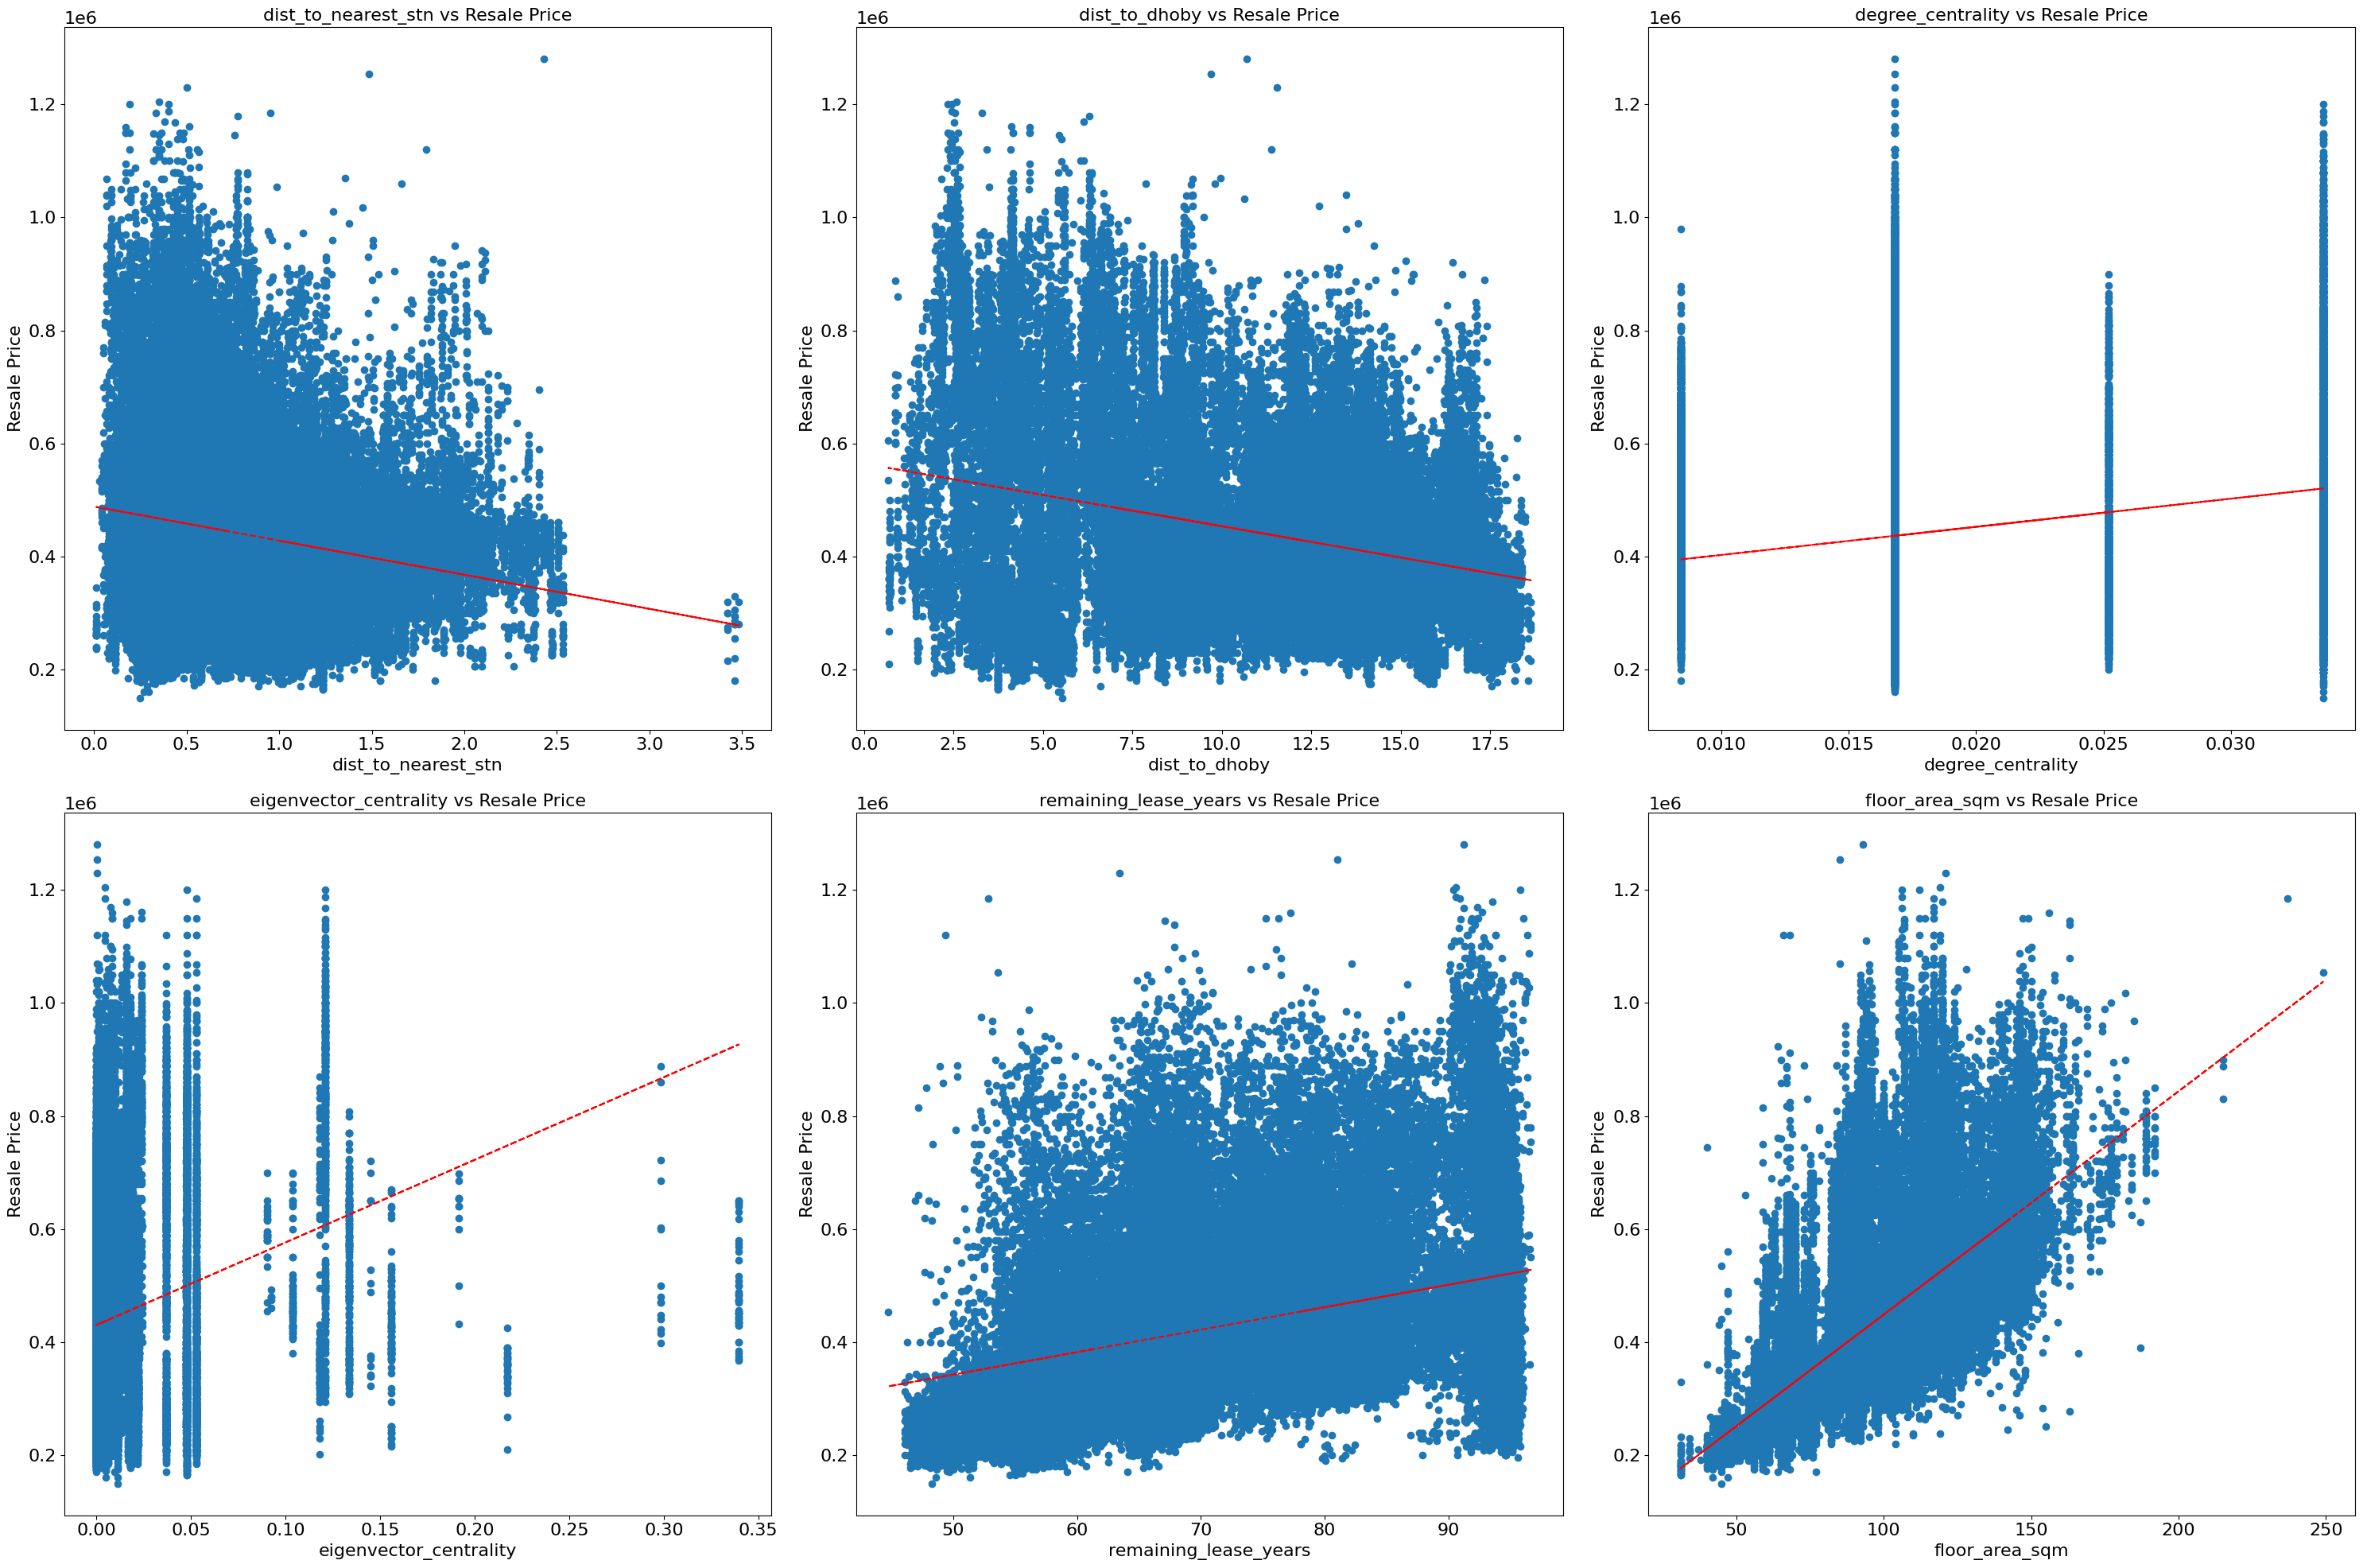

In [30]:
X = np.concatenate([X_train.values, X_test.values], axis=0)
y = np.concatenate([y_train.values, y_test.values], axis=0)

fig, axs = plt.subplots(nrows = 2, ncols = 3, figsize = (30, 20))
for i, (ax, col) in enumerate(zip(axs.flat, numeric_features)):
    x = X[:, i]
    pf = np.polyfit(x, y, 1)
    p = np.poly1d(pf)

    ax.plot(x, y, 'o')
    ax.plot(x, p(x), "r--")

    ax.set_title(col + ' vs Resale Price')
    ax.set_xlabel(col)
    ax.set_ylabel('Resale Price')

plt.tight_layout()
plt.show()

In [14]:
X_train_tensor = torch.tensor(X_train.values).float()
y_train_tensor = torch.tensor(y_train.values).view(-1, 1).float()

X_test_tensor = torch.tensor(X_test.values).float()
y_test_tensor = torch.tensor(y_test.values).view(-1, 1).float()

datasets = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
train_iter = torch.utils.data.DataLoader(datasets, batch_size = batch_size, shuffle = True)

2.Follow this tutorial to generate the plot from various model explainability algorithms (https://captum.ai/tutorials/House_Prices_Regression_Interpret).
Specifically, make the following changes:
- Use a feedforward neural network with 3 hidden layers, each having 5 neurons. Train using Adam optimiser with learning rate of 0.0005.
- Use Saliency, DeepLift, Integrated Gradients, GradientSHAP, Feature Ablation


In [15]:
# YOUR CODE HERE

# Define the model - 3 hidden layers with 5 neurons each
class RegressionMLP(nn.Module):
    def __init__(self, no_features, no_neurons, no_labels):
        super().__init__()
        self.lin1 = nn.Linear(no_features, no_neurons)
        self.relu1 = nn.ReLU()
        self.lin2 = nn.Linear(no_neurons, no_neurons)
        self.relu2 = nn.ReLU()
        self.lin3 = nn.Linear(no_neurons, no_neurons)
        self.relu3 = nn.ReLU()
        self.lin4 = nn.Linear(no_neurons, no_labels)

    def forward(self, input):
        return self.lin4(self.relu3(self.lin3(self.relu2(self.lin2(self.relu1(self.lin1(input)))))))

In [16]:
set_seed(SEED)
model = RegressionMLP(no_features, no_neurons, no_labels)
model.train()

RegressionMLP(
  (lin1): Linear(in_features=6, out_features=5, bias=True)
  (relu1): ReLU()
  (lin2): Linear(in_features=5, out_features=5, bias=True)
  (relu2): ReLU()
  (lin3): Linear(in_features=5, out_features=5, bias=True)
  (relu3): ReLU()
  (lin4): Linear(in_features=5, out_features=1, bias=True)
)

In [17]:
def train(model, num_epochs = no_epochs):
    optimizer = optim.Adam(model.parameters(), lr = learning_rate)
    loss_fn   = nn.MSELoss(reduction = 'sum')

    for epoch in range(num_epochs):
        running_loss = 0.0

        for inputs, labels in train_iter:
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            running_loss += loss.item()
            optimizer.step()

        if epoch % 20 == 0:
            print('Epoch [%d]/[%d] running accumulative loss across all batches: %.3f' %(epoch + 1, num_epochs, running_loss))

        running_loss = 0.0

In [18]:
# Train the Model
train(model, no_epochs)

Epoch [1]/[200] running accumulative loss across all batches: 13725174820110336.000
Epoch [21]/[200] running accumulative loss across all batches: 659208308867072.000
Epoch [41]/[200] running accumulative loss across all batches: 362017038446592.000
Epoch [61]/[200] running accumulative loss across all batches: 350348415057920.000
Epoch [81]/[200] running accumulative loss across all batches: 344630406758400.000
Epoch [101]/[200] running accumulative loss across all batches: 342124873908224.000
Epoch [121]/[200] running accumulative loss across all batches: 340917606887424.000
Epoch [141]/[200] running accumulative loss across all batches: 340307356993024.000
Epoch [161]/[200] running accumulative loss across all batches: 339665561690112.000
Epoch [181]/[200] running accumulative loss across all batches: 310502760424448.000


In [19]:
# Evaluate Model
model.eval()
outputs = model(X_test_tensor)
mse = np.sqrt(mean_squared_error(outputs.detach().numpy(), y_test_tensor.detach().numpy()))

print('Model Error (Mean Squared Error): ', mse)

Model Error (Mean Squared Error):  222105.88437049568


In [20]:
# Calculate Attributions
def calculate_attr(model, X_train_tensor, X_test_tensor):
    ig = IntegratedGradients(model)
    s = Saliency(model)
    dl = DeepLift(model)
    gs = GradientShap(model)
    fa = FeatureAblation(model)

    ig_attr_test = ig.attribute(X_test_tensor, n_steps = 50)
    s_attr_test = s.attribute(X_test_tensor)
    dl_attr_test = dl.attribute(X_test_tensor)
    gs_attr_test = gs.attribute(X_test_tensor, X_train_tensor)
    fa_attr_test = fa.attribute(X_test_tensor)

    return {
        'IG': ig_attr_test,
        'S': s_attr_test,
        'DL': dl_attr_test,
        'GS': gs_attr_test,
        'FA': fa_attr_test
    }

# Plot the Graph
def plot_attributions_graph(model, attributions, X_test_tensor, title):
    x_axis_data = np.arange(X_test_tensor.shape[1])
    x_axis_data_labels = list(map(lambda idx: numeric_features[idx], x_axis_data))

    s_attr_test_sum = attributions['S'].detach().numpy().sum(0)
    s_attr_test_norm_sum = s_attr_test_sum / np.linalg.norm(s_attr_test_sum, ord = 1)

    ig_attr_test_sum = attributions['IG'].detach().numpy().sum(0)
    ig_attr_test_norm_sum = ig_attr_test_sum / np.linalg.norm(ig_attr_test_sum, ord = 1)

    dl_attr_test_sum = attributions['DL'].detach().numpy().sum(0)
    dl_attr_test_norm_sum = dl_attr_test_sum / np.linalg.norm(dl_attr_test_sum, ord = 1)

    gs_attr_test_sum = attributions['GS'].detach().numpy().sum(0)
    gs_attr_test_norm_sum = gs_attr_test_sum / np.linalg.norm(gs_attr_test_sum, ord = 1)

    fa_attr_test_sum = attributions['FA'].detach().numpy().sum(0)
    fa_attr_test_norm_sum = fa_attr_test_sum / np.linalg.norm(fa_attr_test_sum, ord = 1)

    lin_weight = model.lin1.weight[0].detach().numpy()
    y_axis_lin_weight = lin_weight / np.linalg.norm(lin_weight, ord=1)

    width = 0.14
    legends = ['Saliency', 'Integrated Gradients', 'DeepLift', 'GradientShap', 'FeatureAblation', 'Weights']

    plt.figure(figsize = (20, 12))

    ax = plt.subplot()
    ax.set_title(title)
    ax.set_ylabel('Attributions')

    FONT_SIZE = 16
    plt.rc('font', size = FONT_SIZE)            # fontsize of the text sizes
    plt.rc('axes', titlesize = FONT_SIZE)       # fontsize of the axes title
    plt.rc('axes', labelsize = FONT_SIZE)       # fontsize of the x and y labels
    plt.rc('legend', fontsize = FONT_SIZE - 4)  # fontsize of the legend

    ax.bar(x_axis_data, s_attr_test_norm_sum, width, align = 'center', alpha = 0.8, color = '#eb5e7c')
    ax.bar(x_axis_data + width, ig_attr_test_norm_sum, width, align = 'center',  alpha = 0.7, color = '#4260f5')
    ax.bar(x_axis_data + 2 * width, dl_attr_test_norm_sum, width, align = 'center', alpha = 0.6, color = '#49ba81')
    ax.bar(x_axis_data + 3 * width, gs_attr_test_norm_sum, width, align = 'center', alpha = 0.8, color = '#34b8e0')
    ax.bar(x_axis_data + 4 * width, fa_attr_test_norm_sum, width, align = 'center', alpha = 1.0, color = '#A90000')
    ax.bar(x_axis_data + 5 * width, y_axis_lin_weight, width, align = 'center', alpha = 1.0, color = 'grey')
    ax.autoscale_view()
    plt.tight_layout()

    ax.set_xticks(x_axis_data + 0.5)
    ax.set_xticklabels(x_axis_data_labels)

    plt.legend(legends, loc = 3)
    plt.show()

In [21]:
# Calculate Attributions
attributions = calculate_attr(model, X_train_tensor, X_test_tensor)

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


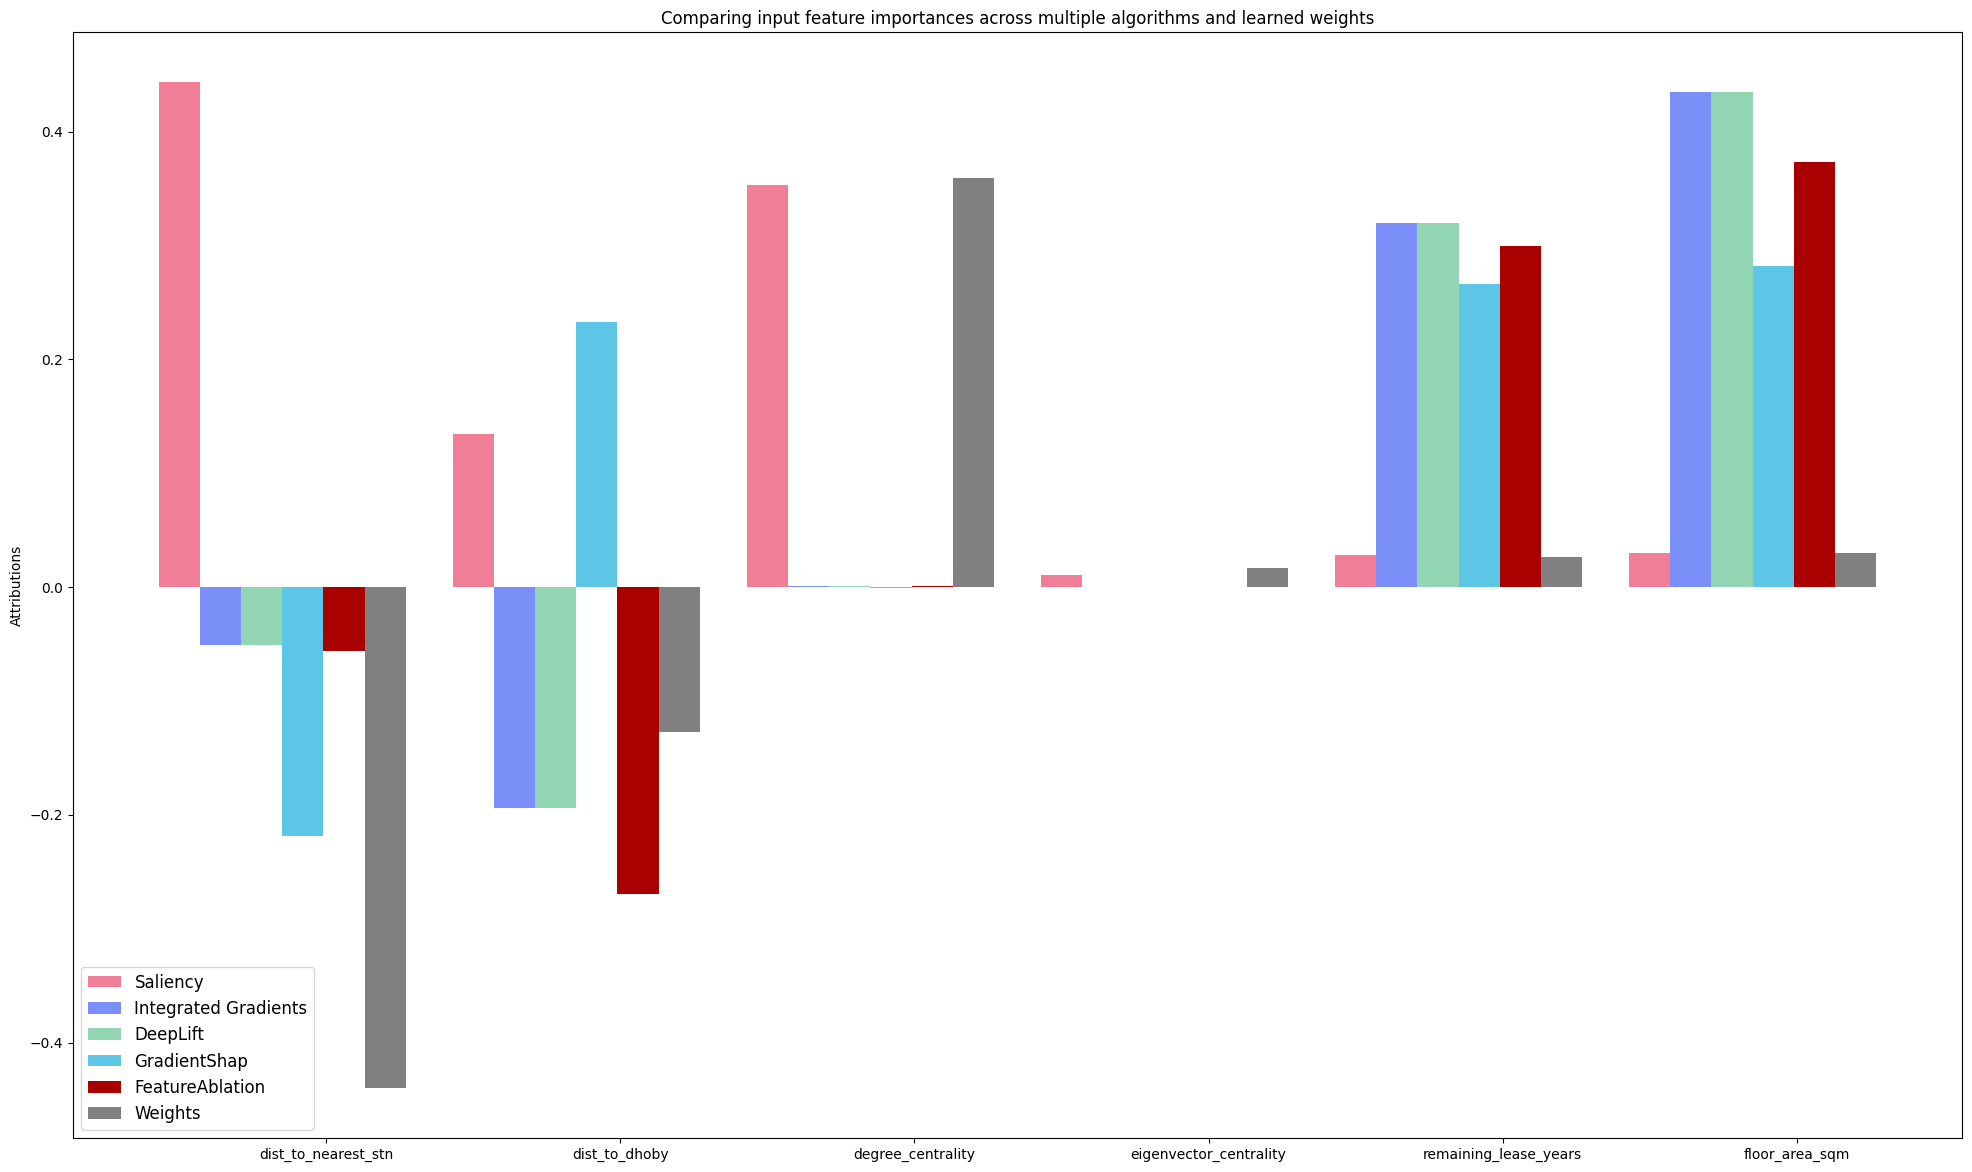

In [22]:
plot_attributions_graph(
    model,
    attributions,
    X_test_tensor,
    'Comparing input feature importances across multiple algorithms and learned weights'
)

3.Train a separate model with the same configuration but now standardise the features via **StandardScaler** (fit to training set, then transform all). State your observations with respect to GradientShap and explain why it has occurred.
(Hint: Many gradient-based approaches depend on a baseline, which is an important choice to be made. Check the default baseline settings carefully.)


In [23]:
# YOUR CODE HERE
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

set_seed(SEED)
scaled_model = RegressionMLP(no_features, no_neurons, no_labels)
scaled_model.train()

RegressionMLP(
  (lin1): Linear(in_features=6, out_features=5, bias=True)
  (relu1): ReLU()
  (lin2): Linear(in_features=5, out_features=5, bias=True)
  (relu2): ReLU()
  (lin3): Linear(in_features=5, out_features=5, bias=True)
  (relu3): ReLU()
  (lin4): Linear(in_features=5, out_features=1, bias=True)
)

In [24]:
X_train_scaled_tensor = torch.tensor(X_train_scaled).float()
X_test_scaled_tensor = torch.tensor(X_test_scaled).float()

In [25]:
train(scaled_model, no_epochs)

Epoch [1]/[200] running accumulative loss across all batches: 13725174820110336.000
Epoch [21]/[200] running accumulative loss across all batches: 659208308867072.000
Epoch [41]/[200] running accumulative loss across all batches: 362017038446592.000
Epoch [61]/[200] running accumulative loss across all batches: 350348415057920.000
Epoch [81]/[200] running accumulative loss across all batches: 344630406758400.000
Epoch [101]/[200] running accumulative loss across all batches: 342124873908224.000
Epoch [121]/[200] running accumulative loss across all batches: 340917606887424.000
Epoch [141]/[200] running accumulative loss across all batches: 340307356993024.000
Epoch [161]/[200] running accumulative loss across all batches: 339665561690112.000
Epoch [181]/[200] running accumulative loss across all batches: 310502760424448.000


In [26]:
# Evaluate Scaled Model
scaled_model.eval()
outputs_scaled = scaled_model(X_test_scaled_tensor)
mse_scaled = np.sqrt(mean_squared_error(outputs_scaled.detach().numpy(), y_test_tensor.detach().numpy()))

print('Model Error (Mean Squared Error): ', mse_scaled)

Model Error (Mean Squared Error):  517855.0498662729


In [27]:
# Calculate Attributions
scaled_attributions = calculate_attr(scaled_model, X_train_scaled_tensor, X_test_scaled_tensor)

/usr/local/lib/python3.12/dist-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/attr/_core/deep_lift.py:294: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
/usr/local/lib/python3.12/dist-packages/captum/log/dummy_log.py:39: UserWarning: Setting forward, backward hooks and attributes on non-linear
               activations. The hooks and attributes will be removed
            after the attribution is finished
  return func(*args, **kwargs)


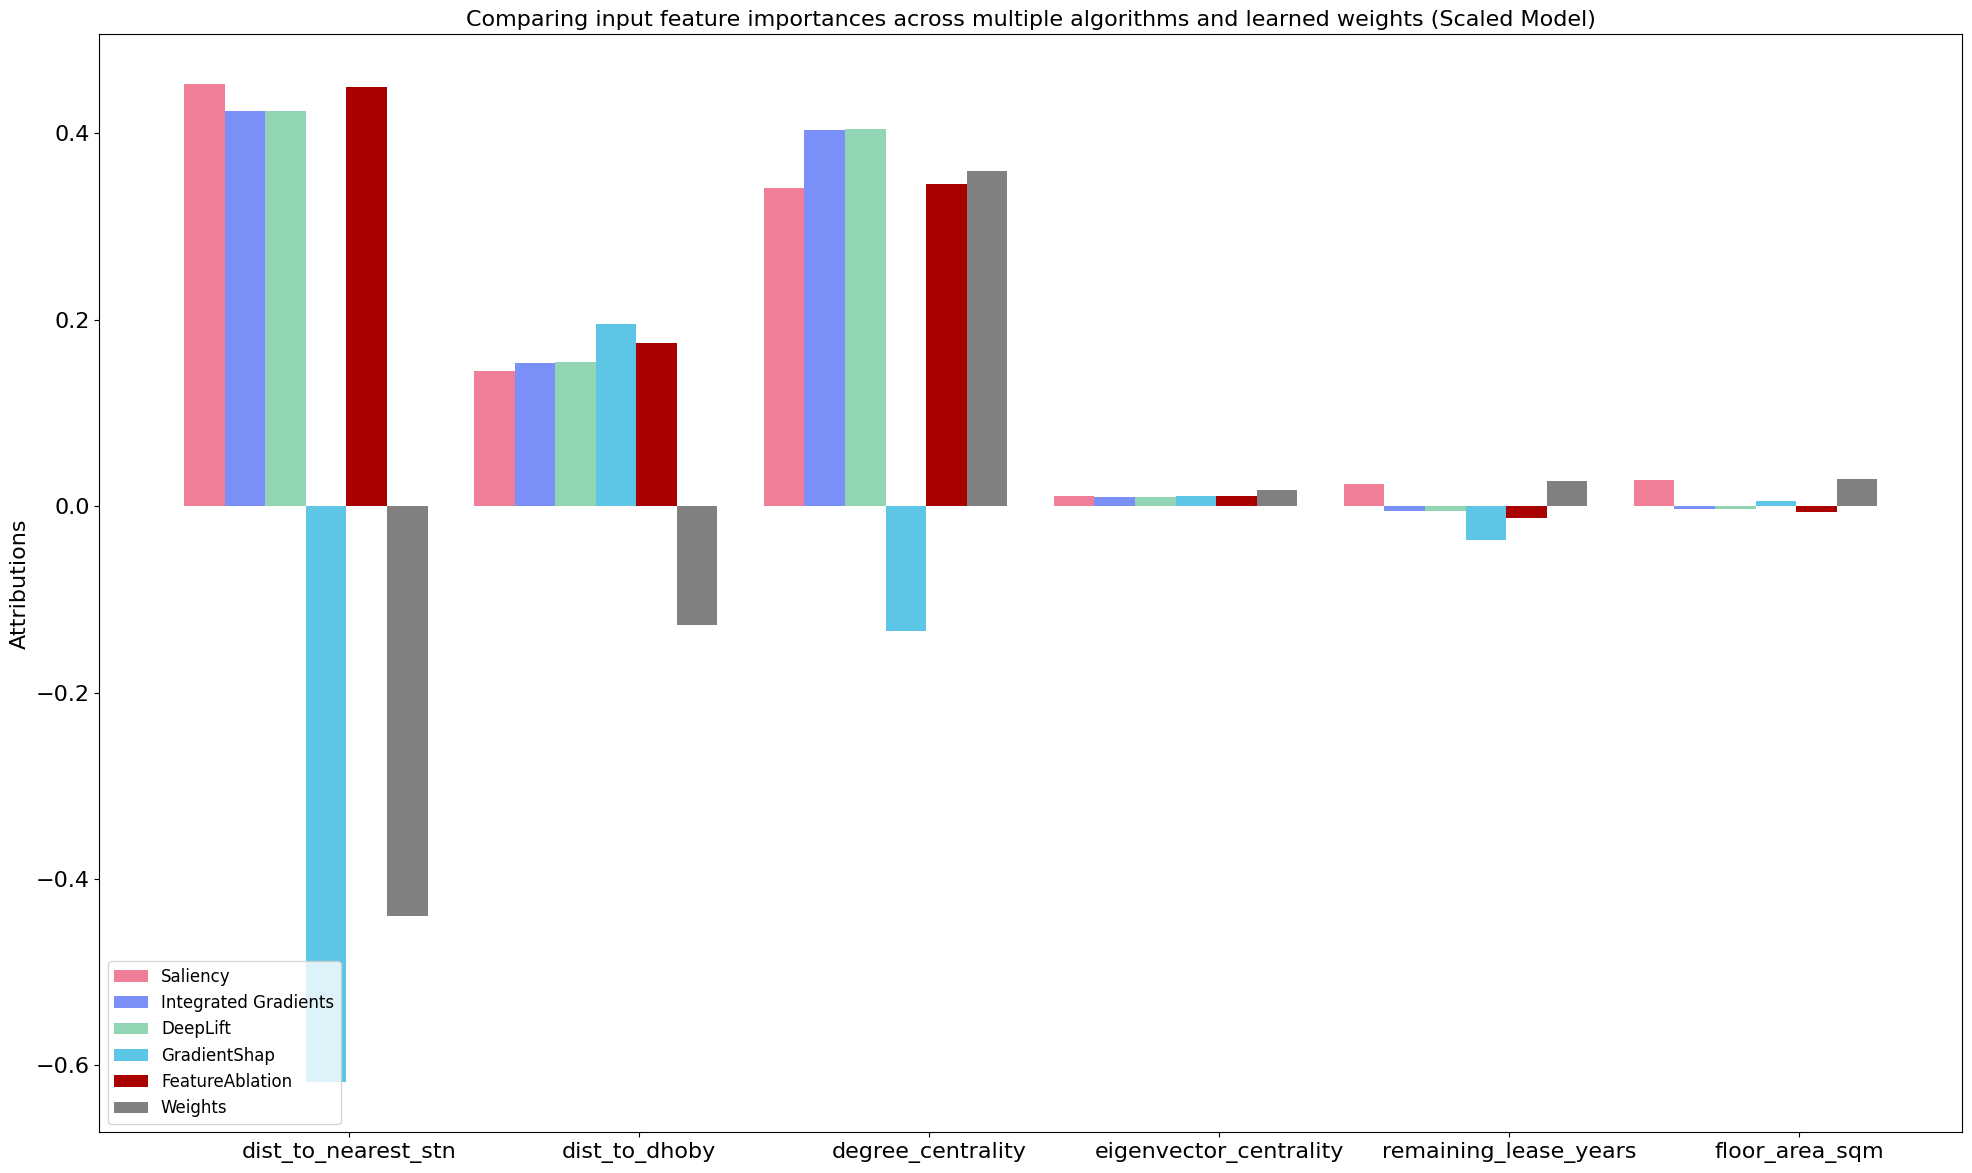

In [28]:
plot_attributions_graph(
    scaled_model,
    scaled_attributions,
    X_test_scaled_tensor,
    'Comparing input feature importances across multiple algorithms and learned weights (Scaled Model)'
)

Unscaled model:
GradientSHAP shows diverging results from other methods. For example, a large positive attribution (around 0.23) for dist_to_dhoby while Integrated Gradients and DeepLift show negative values for the same feature.

Scaled model:
This discrepancy becomes even more extreme, GradientSHAP produces an extreme negative attribution (around -0.6) for dist_to_nearest_stn, drastically differing from all other methods which consistently show positive attributions (roughly 0.4) for the same feature.

This occurred because when using gradient-based attribution methods like GradientSHAP, the choice of baseline is crucial as it serves as a reference point to compute attributions by comparing the model's output at the baseline versus at the actual input. GradientSHAP uses a default baseline of zeros, which means all feature values are set to zero as the reference.
In the unscaled model, zero is already an unrealistic reference point since raw feature values like floor_area_sqm or dist_to_dhoby are never zero in practice, causing GradientSHAP to diverge from other methods. When StandardScaler is applied, the mean of each feature becomes 0 and standard deviation becomes 1, meaning the zero baseline now represents the average sample. This causes GradientSHAP to attribute importance based on how far each input deviates from zero in either direction, which explains the extreme attribution seen for dist_to_nearest_stn in the scaled model.

To obtain more reliable insights, a custom baseline such as the training data distribution should be used instead of the default zero baseline.

Read https://distill.pub/2020/attribution-baselines/ to build up your understanding of Integrated Gradients (IG). Reading the sections before the section on ‘Game Theory and Missingness’ will be sufficient. Keep in mind that this article mainly focuses on classification problems. You might find the following [descriptions](https://captum.ai/docs/attribution_algorithms) and [comparisons](https://captum.ai/docs/algorithms_comparison_matrix) in Captum useful as well.


Then, identify the algorithms that produced similar results, if any, and explain why in the context of our dataset. If no methods appear similar, discuss possible reasons for the differences


In [29]:
# YOUR ANSWER HERE

Methods that produced similar results:

Unscaled model:
Integrated Gradients and DeepLift show the most similar results, in fact their attribution scores are almost exactly the same in all 6 features no matter in the negative or positive directions.

Scaled model:
Integrated Gradients and DeepLift also shows the most similar results, similar to the unscaled model, the attribution scores for these 2 are almost identical in both negative and positive directions.

Why Integrated Gradients and DeepLift produce similar results:
As described in the article, both Integrated Gradients and DeepLift are path attribution methods, which means that they both compute attributions by measuring how the model output changes as the input moves from the baseline to the actual input. Both methods also share the completeness axiom, meaning their attributions sum to the difference between the model's output at the actual input and at the baseline. DeepLift achieves a similar effect to Integrated Gradients because it propagates differences from the baseline back through the network layer by layer, which closely approximates the path integral that Integrated Gradients computes. This connection explains why they agree, and even output similar results.